In [ ]:
# Update pip and install required packages
!pip install --upgrade pip

# Install core packages
!pip install numpy scipy matplotlib pandas

# Medical imaging libraries
!pip install pydicom nibabel SimpleITK

# General image processing
!pip install scikit-image opencv-python

!pip install fastmri nibabel

In [ ]:
!pip install requests h5py

In [ ]:
# !tar -xvf drive/MyDrive/ai-ml/knee_singlecoil_test.tar

In [ ]:
import os
# environment variable to handle OpenMP conflicts before importing other libraries
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import h5py
import numpy as np
import matplotlib.pyplot as plt
# Import reconstruction function from fastmri
try:
    from fastmri.fftc import ifft2c_new
    FASTMRI_AVAILABLE = True
    print("FastMRI library imported successfully.")
except ImportError as e:
    print(f"FastMRI import failed: {e}")
    print("Will use manual reconstruction with numpy FFT.")
    FASTMRI_AVAILABLE = False
import nibabel as nib


FastMRI library imported successfully.


## EXPLORING THE .H5 FILES

In [ ]:
# --- Configuration ---
# knee_singlecoil_test folder
data_folder = "singlecoil_test/"
# Find one .h5 file to inspect
h5_file_path = None
for root, _, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".h5"):
            h5_file_path = os.path.join(root, file)
            break
    if h5_file_path:
        break

if h5_file_path is None:
    print(f"Error: No .h5 files found in {data_folder}. Please check the path and contents.")
    exit()

print(f"Inspecting file: {h5_file_path}")

Inspecting file: singlecoil_test/file1000692.h5


In [ ]:
import h5py
import numpy as np
import os
from PIL import Image # For saving as PNG
import nibabel as nib # For saving as NIfTI
from fastmri.fftc import ifft2c_new

# --- Configuration ---
input_data_folder = "D:\\knee_singlecoil_test\\singlecoil_test"
output_folder_png = "./processed_images_png" # Output for PNGs
output_folder_npy = "./processed_images_npy" # Output for NumPy arrays (for ML)
output_folder_nifti = "./processed_images_nifti" # Output for NIfTI (medical image format)

max_files_to_process = 10 # Process only 10 files for testing as requested

# Ensure output directories exist
os.makedirs(output_folder_png, exist_ok=True)
os.makedirs(output_folder_npy, exist_ok=True)
os.makedirs(output_folder_nifti, exist_ok=True)

print(f"Starting preprocessing from: {input_data_folder}")
print(f"Output PNGs to: {output_folder_png}")
print(f"Output NumPy arrays to: {output_folder_npy}")
print(f"Output NIfTI files to: {output_folder_nifti}")
print(f"Processing a maximum of {max_files_to_process} files.")

processed_count = 0

# Variables to store data for visualization from the first processed file
example_raw_image_data = None
example_normalized_image_data = None
example_kspace_data = None # To visualize k-space vs. image
example_reco_magnitude_slice = None # To visualize k-space vs. image

for root, _, files in os.walk(input_data_folder):
    for filename in files:
        if filename.endswith(".h5"):
            if processed_count >= max_files_to_process:
                print(f"Reached maximum of {max_files_to_process} files. Stopping.")
                break

            file_path = os.path.join(root, filename)
            scan_id = os.path.splitext(filename)[0] # e.g., 'file1000000'

            print(f"\nProcessing {scan_id}...")

            try:
                current_image_data = None # This will hold the raw or reconstructed image data
                with h5py.File(file_path, 'r') as f:
                    # Prefer 'reconstruction_rss' or 'reconstruction_esc' if they exist (though unlikely for your current files)
                    if 'reconstruction_rss' in f:
                        current_image_data = f['reconstruction_rss'][()]
                        print(f"  Loaded 'reconstruction_rss' with shape: {current_image_data.shape}")
                    elif 'reconstruction_esc' in f:
                        current_image_data = f['reconstruction_esc'][()]
                        print(f"  Loaded 'reconstruction_esc' with shape: {current_image_data.shape}")
                    elif 'kspace' in f:
                        print(f"  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.")
                        kspace_data = f['kspace'][()] # Keep kspace_data for example visualization

                        reconstructed_slices = []
                        for i in range(kspace_data.shape[0]): # Iterate through slices
                            slice_kspace_complex = kspace_data[i]  # (height, width) complex data

                            # Convert numpy complex to tensor with separate complex dimension
                            if np.iscomplexobj(slice_kspace_complex):
                                # Stack real and imaginary parts as last dimension
                                slice_kspace_separated = np.stack([slice_kspace_complex.real, slice_kspace_complex.imag], axis=-1)
                                # Add coil dimension: (1, height, width, 2)
                                slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)
                            else:
                                print(f"  Warning: k-space slice {i} is not complex. Creating zero imaginary part.")
                                slice_kspace_separated = np.stack([slice_kspace_complex, np.zeros_like(slice_kspace_complex)], axis=-1)
                                slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)

                            try:
                                reco_slice_complex_separated = ifft2c_new(slice_kspace_reshaped)

                                # Convert back to numpy complex format for magnitude calculation
                                if reco_slice_complex_separated.shape[-1] == 2:  # Has complex dimension
                                    reco_complex_numpy = reco_slice_complex_separated[..., 0] + 1j * reco_slice_complex_separated[..., 1]
                                else:
                                    reco_complex_numpy = reco_slice_complex_separated

                                # Take magnitude of the single coil
                                reco_slice_magnitude = np.abs(reco_complex_numpy[0])  # Remove coil dimension

                            except Exception as e:
                                print(f"  FastMRI reconstruction failed for slice {i}: {e}")
                                print("  Falling back to manual inverse FFT...")
                                reco_slice_complex = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(slice_kspace_complex)))
                                reco_slice_magnitude = np.abs(reco_slice_complex)

                            reconstructed_slices.append(reco_slice_magnitude)

                        current_image_data = np.stack(reconstructed_slices, axis=0)
                        print(f"  Reconstructed image data shape: {current_image_data.shape}")

                        # If this is the first file processed, store k-space and reconstructed slice for visualization
                        if example_kspace_data is None:
                            example_kspace_data = kspace_data[current_image_data.shape[0] // 2] # Middle slice k-space
                            example_reco_magnitude_slice = current_image_data[current_image_data.shape[0] // 2] # Middle reconstructed slice
                    else:
                        print(f"  No reconstructible data ('reconstruction_rss', 'reconstruction_esc', or 'kspace') found in {filename}. Skipping.")
                        continue # Skip to the next file

                    # Ensure the data is real (if it's complex, take the absolute value)
                    if np.iscomplexobj(current_image_data):
                        current_image_data = np.abs(current_image_data)
                        print("  Converted complex image data to absolute values (post-reconstruction).")

                    # Store a copy of the pre-normalized data if it's the first file
                    if example_raw_image_data is None:
                        # Take the middle slice for consistency with other visualizations
                        middle_slice_index = current_image_data.shape[0] // 2
                        example_raw_image_data = current_image_data[middle_slice_index].copy()
                        print(f"  Stored raw data from middle slice {middle_slice_index} for visualization.")


                    # Normalization: Scale values to 0-1
                    min_val = np.min(current_image_data)
                    max_val = np.max(current_image_data)
                    if max_val - min_val > 0:
                        normalized_image_data_current = (current_image_data - min_val) / (max_val - min_val)
                        print(f"  Normalized image data from [{min_val:.2f}, {max_val:.2f}] to [0, 1].")
                    else:
                        normalized_image_data_current = current_image_data # Already uniform, no change
                        print("  Image data is uniform, skipping normalization.")

                    # Store a copy of the post-normalized data if it's the first file
                    if example_normalized_image_data is None:
                        # Take the middle slice for consistency
                        example_normalized_image_data = normalized_image_data_current[middle_slice_index].copy()
                        print(f"  Stored normalized data from middle slice {middle_slice_index} for visualization.")


                    # Assuming normalized_image_data_current is (slices, height, width)
                    num_slices = normalized_image_data_current.shape[0]

                    # --- Save as NIfTI (.nii.gz) for 3D medical imaging ---
                    nifti_data = normalized_image_data_current.transpose(1, 2, 0) # (height, width, slices)
                    affine = np.eye(4) # Identity affine matrix for basic NIfTI save
                    nifti_img = nib.Nifti1Image(nifti_data.astype(np.float32), affine) # Save as float32
                    nifti_output_path = os.path.join(output_folder_nifti, f"{scan_id}.nii.gz")
                    nib.save(nifti_img, nifti_output_path)
                    print(f"  Saved 3D NIfTI: {nifti_output_path}")


                    # --- Save each slice as PNG (for visualization) and NumPy array (for ML) ---
                    for i in range(num_slices):
                        slice_data = normalized_image_data_current[i] # Slice is now (height, width)

                        # Save as PNG (scaled to 0-255 for typical image display)
                        png_data = (slice_data * 255).astype(np.uint8)
                        png_filename = f"{scan_id}_slice_{i:03d}.png"
                        Image.fromarray(png_data).save(os.path.join(output_folder_png, png_filename))

                        # Save as NumPy array (float32 for ML input)
                        npy_filename = f"{scan_id}_slice_{i:03d}.npy"
                        np.save(os.path.join(output_folder_npy, npy_filename), slice_data.astype(np.float32))

                    print(f"  Processed {num_slices} slices for {scan_id}.")
                    processed_count += 1

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
                import traceback
                traceback.print_exc() # Print full traceback for debugging

print(f"\nPreprocessing finished. Processed {processed_count} files.")
print(f"Check '{output_folder_png}', '{output_folder_npy}', and '{output_folder_nifti}' for results.")

# --- Save the example data for later visualization in a separate notebook/script ---
# This is optional, but useful if you want to run visualizations in a different cell/file
if example_raw_image_data is not None:
    np.save('example_raw_image_slice.npy', example_raw_image_data)
    np.save('example_normalized_image_slice.npy', example_normalized_image_data)
    np.save('example_kspace_slice.npy', example_kspace_data)
    np.save('example_reco_magnitude_slice.npy', example_reco_magnitude_slice)
    print("\nExample data (raw, normalized, kspace, reconstructed) saved as .npy files for visualization.")


Starting preprocessing from: D:\knee_singlecoil_test\singlecoil_test
Output PNGs to: ./processed_images_png
Output NumPy arrays to: ./processed_images_npy
Output NIfTI files to: ./processed_images_nifti
Processing a maximum of 10 files.

Preprocessing finished. Processed 0 files.
Check './processed_images_png', './processed_images_npy', and './processed_images_nifti' for results.



--- H5 File Structure ---
ismrmrd_header
kspace
mask

--- Available Keys/Datasets ---
- ismrmrd_header
- kspace
- mask

--- 'reconstruction_rss' not found. Performing reconstruction from 'kspace' data ---
Shape of kspace_data: (36, 640, 368)
Data type: complex64
Is complex: True
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped shape: (1, 640, 368, 2)
Debug: slice_kspace_reshaped s

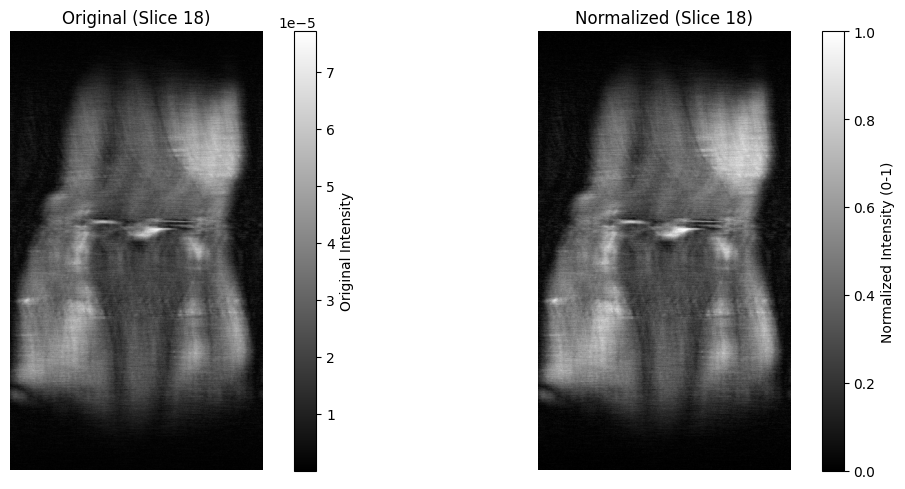

In [ ]:
try:
    with h5py.File(h5_file_path, 'r') as f:
        print("\n--- H5 File Structure ---")
        def print_attrs(name, obj):
            print(name)
            for key, val in obj.attrs.items():
                print(f"    {key}: {val}")
        f.visititems(print_attrs)

        print("\n--- Available Keys/Datasets ---")
        for key in f.keys():
            print(f"- {key}")

        # check for 'reconstruction_rss' / 'reconstruction_esc'
        if 'reconstruction_rss' in f:
            print("\n--- Extracting 'reconstruction_rss' data (already reconstructed) ---")
            image_data = f['reconstruction_rss'][()]
            print(f"Shape of image_data: {image_data.shape}")
            print(f"Data type: {image_data.dtype}")
            print(f"Min value: {np.min(image_data)}")
            print(f"Max value: {np.max(image_data)}")
            # Handle potential complex data
            if np.iscomplexobj(image_data):
                image_data = np.abs(image_data)

            # Display logic
            if image_data.ndim >= 3:
                middle_slice_index = image_data.shape[0] // 2
                slice_to_display = image_data[middle_slice_index]
                if slice_to_display.ndim == 3: # If still (coils, height, width), take the first coil
                    print(f"Warning: Slice has 3 dimensions ({slice_to_display.shape}), showing first 'coil' or channel.")
                    slice_to_display = slice_to_display[0]

                plt.figure(figsize=(8, 8))
                plt.imshow(slice_to_display, cmap='gray') # Already took abs above if complex
                plt.title(f'Middle Slice (Index: {middle_slice_index}) from reconstruction_rss')
                plt.colorbar(label='Pixel Intensity')
                plt.axis('off')
                plt.show()
            else:
                print("Image data has fewer than 3 dimensions, cannot display as a slice image.")

        elif 'kspace' in f:
            print("\n--- 'reconstruction_rss' not found. Performing reconstruction from 'kspace' data ---")
            kspace_data = f['kspace'][()]
            print(f"Shape of kspace_data: {kspace_data.shape}")
            print(f"Data type: {kspace_data.dtype}")
            print(f"Is complex: {np.iscomplexobj(kspace_data)}")

            # --- Reconstruction using fastMRI's ifft2c_new or manual FFT ---
            # fastMRI expects data with a separate complex dimension (real, imag)
            # but numpy complex data has complex values as a single type

            reconstructed_slices = []
            for i in range(kspace_data.shape[0]): # Iterate through slices
                slice_kspace_complex = kspace_data[i]  # (height, width) complex data

                if FASTMRI_AVAILABLE:
                    try:
                        # Convert numpy complex to tensor with separate complex dimension
                        if np.iscomplexobj(slice_kspace_complex):
                            # Stack real and imaginary parts as last dimension
                            slice_kspace_separated = np.stack([slice_kspace_complex.real, slice_kspace_complex.imag], axis=-1)
                            # Add coil dimension: (1, height, width, 2)
                            slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)
                        else:
                            print(f"Warning: k-space slice {i} is not complex. Creating zero imaginary part.")
                            slice_kspace_separated = np.stack([slice_kspace_complex, np.zeros_like(slice_kspace_complex)], axis=-1)
                            slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)

                        print(f"Debug: slice_kspace_reshaped shape: {slice_kspace_reshaped.shape}")

                        # Try to convert to torch tensor if needed (fastMRI might expect torch tensors)
                        try:
                            import torch
                            slice_kspace_tensor = torch.from_numpy(slice_kspace_reshaped.astype(np.float32))
                            reco_slice_complex_separated = ifft2c_new(slice_kspace_tensor).numpy()
                        except ImportError:
                            # If torch is not available, try with numpy array directly
                            reco_slice_complex_separated = ifft2c_new(slice_kspace_reshaped)

                        # Convert back to numpy complex format for magnitude calculation
                        if reco_slice_complex_separated.shape[-1] == 2:  # Has complex dimension
                            reco_complex_numpy = reco_slice_complex_separated[..., 0] + 1j * reco_slice_complex_separated[..., 1]
                        else:
                            reco_complex_numpy = reco_slice_complex_separated

                        # Take magnitude of the single coil
                        reco_slice_magnitude = np.abs(reco_complex_numpy[0])  # Remove coil dimension

                    except Exception as e:
                        print(f"FastMRI reconstruction failed for slice {i}: {e}")
                        print("Falling back to manual inverse FFT...")
                        FASTMRI_AVAILABLE = False  # Disable for remaining slices
                        reco_slice_complex = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(slice_kspace_complex)))
                        reco_slice_magnitude = np.abs(reco_slice_complex)
                else:
                    # Manual reconstruction using numpy FFT
                    reco_slice_complex = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(slice_kspace_complex)))
                    reco_slice_magnitude = np.abs(reco_slice_complex)

                reconstructed_slices.append(reco_slice_magnitude)

            # Stack the reconstructed slices back into a 3D volume
            image_data = np.stack(reconstructed_slices, axis=0)
            print(f"  Reconstructed image data shape: {image_data.shape}")
            print(f"  Data type after reconstruction: {image_data.dtype}")
            print(f"  Min value: {np.min(image_data)}")
            print(f"  Max value: {np.max(image_data)}")

            # Normalize the image data for better visualization
            # Remove any zero or very small background values for better contrast
            image_data_norm = image_data.copy()

            # Apply percentile-based normalization to improve contrast
            p1, p99 = np.percentile(image_data_norm, [1, 99])
            image_data_norm = np.clip(image_data_norm, p1, p99)

            # Normalize to 0-1 range
            if np.max(image_data_norm) > np.min(image_data_norm):
                image_data_norm = (image_data_norm - np.min(image_data_norm)) / (np.max(image_data_norm) - np.min(image_data_norm))

            print(f"  After normalization - Min: {np.min(image_data_norm)}, Max: {np.max(image_data_norm)}")

            # Display the middle slice
            middle_slice_index = image_data.shape[0] // 2
            slice_to_display = image_data_norm[middle_slice_index]

            plt.figure(figsize=(12, 5))

            # Original data
            plt.subplot(1, 2, 1)
            plt.imshow(image_data[middle_slice_index], cmap='gray')
            plt.title(f'Original (Slice {middle_slice_index})')
            plt.colorbar(label='Original Intensity')
            plt.axis('off')

            # Normalized data
            plt.subplot(1, 2, 2)
            plt.imshow(slice_to_display, cmap='gray')
            plt.title(f'Normalized (Slice {middle_slice_index})')
            plt.colorbar(label='Normalized Intensity (0-1)')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        else:
            print("Neither 'reconstruction_rss', 'reconstruction_esc', nor 'kspace' found. Cannot display image.")

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the .h5 file is not corrupted, the path is correct, and fastmri is installed.")
    import traceback
    traceback.print_exc()

## PREPROCESSING MRI IMAGES

In [ ]:
from PIL import Image
# Set environment variable to handle OpenMP conflicts before importing other libraries
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
input_data_folder = "singlecoil_test" # Use raw string or forward slashes for paths
output_folder_png = "./processed_images_png" # Output for PNGs
output_folder_npy = "./processed_images_npy" # Output for NumPy arrays (for ML)
output_folder_nifti = "./processed_images_nifti" # Output for NIfTI (medical image format)
max_files_to_process = 10  # Process only 10 files for testing

# Ensure output directories exist
os.makedirs(output_folder_png, exist_ok=True)
os.makedirs(output_folder_npy, exist_ok=True)
os.makedirs(output_folder_nifti, exist_ok=True)

print(f"Starting preprocessing from: {input_data_folder}")
print(f"Output PNGs to: {output_folder_png}")
print(f"Output NumPy arrays to: {output_folder_npy}")
print(f"Output NIfTI files to: {output_folder_nifti}")
print(f"Processing a maximum of {max_files_to_process} files.")

Starting preprocessing from: singlecoil_test
Output PNGs to: ./processed_images_png
Output NumPy arrays to: ./processed_images_npy
Output NIfTI files to: ./processed_images_nifti
Processing a maximum of 10 files.


In [ ]:
processed_count = 0

for root, _, files in os.walk(input_data_folder):
    for filename in files:
        if filename.endswith(".h5"):
            if processed_count >= max_files_to_process:
                print(f"Reached maximum of {max_files_to_process} files. Stopping.")
                break

            file_path = os.path.join(root, filename)
            scan_id = os.path.splitext(filename)[0] # e.g., 'file1000000'

            print(f"\nProcessing {scan_id}...")

            try:
                image_data = None # Initialize image_data
                with h5py.File(file_path, 'r') as f:
                    # Prefer 'reconstruction_rss' or 'reconstruction_esc' if they exist (though unlikely for your current files)
                    if 'reconstruction_rss' in f:
                        image_data = f['reconstruction_rss'][()]
                        print(f"  Loaded 'reconstruction_rss' with shape: {image_data.shape}")
                    elif 'reconstruction_esc' in f:
                        image_data = f['reconstruction_esc'][()]
                        print(f"  Loaded 'reconstruction_esc' with shape: {image_data.shape}")
                    elif 'kspace' in f:
                        print(f"  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.")
                        kspace_data = f['kspace'][()]
                        print(f"  K-space data shape: {kspace_data.shape}")
                        print(f"  K-space data type: {kspace_data.dtype}")
                        print(f"  Is complex: {np.iscomplexobj(kspace_data)}")

                        reconstructed_slices = []
                        for i in range(kspace_data.shape[0]): # Iterate through slices
                            slice_kspace_complex = kspace_data[i]  # (height, width) complex data

                            if FASTMRI_AVAILABLE:
                                try:
                                    # Convert numpy complex to tensor with separate complex dimension
                                    if np.iscomplexobj(slice_kspace_complex):
                                        # Stack real and imaginary parts as last dimension
                                        slice_kspace_separated = np.stack([slice_kspace_complex.real, slice_kspace_complex.imag], axis=-1)
                                        # Add coil dimension: (1, height, width, 2)
                                        slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)
                                    else:
                                        print(f"  Warning: k-space slice {i} is not complex. Creating zero imaginary part.")
                                        slice_kspace_separated = np.stack([slice_kspace_complex, np.zeros_like(slice_kspace_complex)], axis=-1)
                                        slice_kspace_reshaped = np.expand_dims(slice_kspace_separated, axis=0)

                                    # Try to convert to torch tensor if needed (fastMRI might expect torch tensors)
                                    try:
                                        import torch
                                        slice_kspace_tensor = torch.from_numpy(slice_kspace_reshaped.astype(np.float32))
                                        reco_slice_complex_separated = ifft2c_new(slice_kspace_tensor).numpy()
                                    except ImportError:
                                        # If torch is not available, try with numpy array directly
                                        reco_slice_complex_separated = ifft2c_new(slice_kspace_reshaped)

                                    # Convert back to numpy complex format for magnitude calculation
                                    if reco_slice_complex_separated.shape[-1] == 2:  # Has complex dimension
                                        reco_complex_numpy = reco_slice_complex_separated[..., 0] + 1j * reco_slice_complex_separated[..., 1]
                                    else:
                                        reco_complex_numpy = reco_slice_complex_separated

                                    # Take magnitude of the single coil
                                    reco_slice_magnitude = np.abs(reco_complex_numpy[0])  # Remove coil dimension

                                except Exception as e:
                                    print(f"  FastMRI reconstruction failed for slice {i}: {e}")
                                    print("  Falling back to manual inverse FFT...")
                                    FASTMRI_AVAILABLE = False  # Disable for remaining slices
                                    reco_slice_complex = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(slice_kspace_complex)))
                                    reco_slice_magnitude = np.abs(reco_slice_complex)
                            else:
                                # Manual reconstruction using numpy FFT
                                reco_slice_complex = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(slice_kspace_complex)))
                                reco_slice_magnitude = np.abs(reco_slice_complex)

                            reconstructed_slices.append(reco_slice_magnitude)

                        image_data = np.stack(reconstructed_slices, axis=0)
                        print(f"  Reconstructed image data shape: {image_data.shape}")
                    else:
                        print(f"  No reconstructible data ('reconstruction_rss', 'reconstruction_esc', or 'kspace') found in {filename}. Skipping.")
                        continue # Skip to the next file

                    # Ensure the data is real (if it's complex, take the absolute value)
                    if np.iscomplexobj(image_data): # This check is redundant if we take np.abs during kspace reconstruction
                        image_data = np.abs(image_data)
                        print("  Converted complex image data to absolute values (post-reconstruction).")


                    # Normalization: Scale values to 0-1 with percentile-based clipping for better contrast
                    min_val = np.min(image_data)
                    max_val = np.max(image_data)
                    print(f"  Original data range: [{min_val:.2e}, {max_val:.2e}]")

                    if max_val - min_val > 0:
                        # Apply percentile-based normalization to improve contrast
                        p1, p99 = np.percentile(image_data, [1, 99])
                        print(f"  1st-99th percentile range: [{p1:.2e}, {p99:.2e}]")

                        # Clip to percentile range and normalize
                        clipped_data = np.clip(image_data, p1, p99)
                        if p99 > p1:
                            normalized_image_data = (clipped_data - p1) / (p99 - p1)
                        else:
                            normalized_image_data = clipped_data

                        print(f"  Normalized image data to [0, 1] using percentile clipping.")
                    else:
                        normalized_image_data = image_data # Already uniform, no change
                        print("  Image data is uniform, skipping normalization.")

                    # Assuming normalized_image_data is (slices, height, width)
                    num_slices = normalized_image_data.shape[0]

                    # --- Save as NIfTI (.nii.gz) for 3D medical imaging ---
                    nifti_data = normalized_image_data.transpose(1, 2, 0) # (height, width, slices)
                    affine = np.eye(4) # Identity affine matrix for basic NIfTI save
                    nifti_img = nib.Nifti1Image(nifti_data.astype(np.float32), affine) # Save as float32
                    nifti_output_path = os.path.join(output_folder_nifti, f"{scan_id}.nii.gz")
                    nib.save(nifti_img, nifti_output_path)
                    print(f"  Saved 3D NIfTI: {nifti_output_path}")


                    # --- Save each slice as PNG (for visualization) and NumPy array (for ML) ---
                    for i in range(num_slices):
                        slice_data = normalized_image_data[i] # Slice is now (height, width)

                        # Save as PNG (scaled to 0-255 for typical image display)
                        png_data = (slice_data * 255).astype(np.uint8)
                        png_filename = f"{scan_id}_slice_{i:03d}.png"
                        Image.fromarray(png_data).save(os.path.join(output_folder_png, png_filename))

                        # Save as NumPy array (float32 for ML input)
                        npy_filename = f"{scan_id}_slice_{i:03d}.npy"
                        np.save(os.path.join(output_folder_npy, npy_filename), slice_data.astype(np.float32))

                    print(f"  Processed {num_slices} slices for {scan_id}.")
                    processed_count += 1

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
                import traceback
                traceback.print_exc() # Print full traceback for debugging

print(f"\nPreprocessing finished. Processed {processed_count} files.")
print(f"Check '{output_folder_png}', '{output_folder_npy}', and '{output_folder_nifti}' for results.")



Processing file1000692...
  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.
  K-space data shape: (36, 640, 368)
  K-space data type: complex64
  Is complex: True
  Reconstructed image data shape: (36, 640, 368)
  Original data range: [8.34e-10, 1.47e-04]
  1st-99th percentile range: [2.85e-07, 7.03e-05]
  Normalized image data to [0, 1] using percentile clipping.
  Saved 3D NIfTI: ./processed_images_nifti/file1000692.nii.gz
  Processed 36 slices for file1000692.

Processing file1000751...
  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.
  K-space data shape: (44, 640, 356)
  K-space data type: complex64
  Is complex: True
  Reconstructed image data shape: (44, 640, 356)
  Original data range: [6.50e-10, 1.66e-04]
  1st-99th percentile range: [3.41e-07, 8.41e-05]
  Normalized image data to [0, 1] using percentile clipping.
  Saved 3D NIfTI: ./processed_images_nifti/file1000751.nii.gz
  Processed 44 slices for file1

## Visualizations

Example data loaded successfully for visualization.


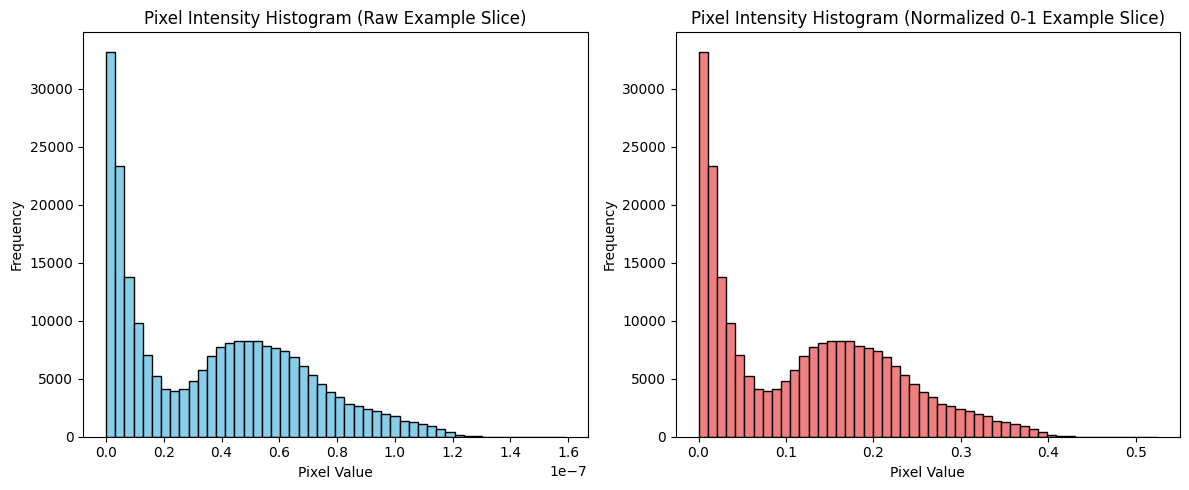

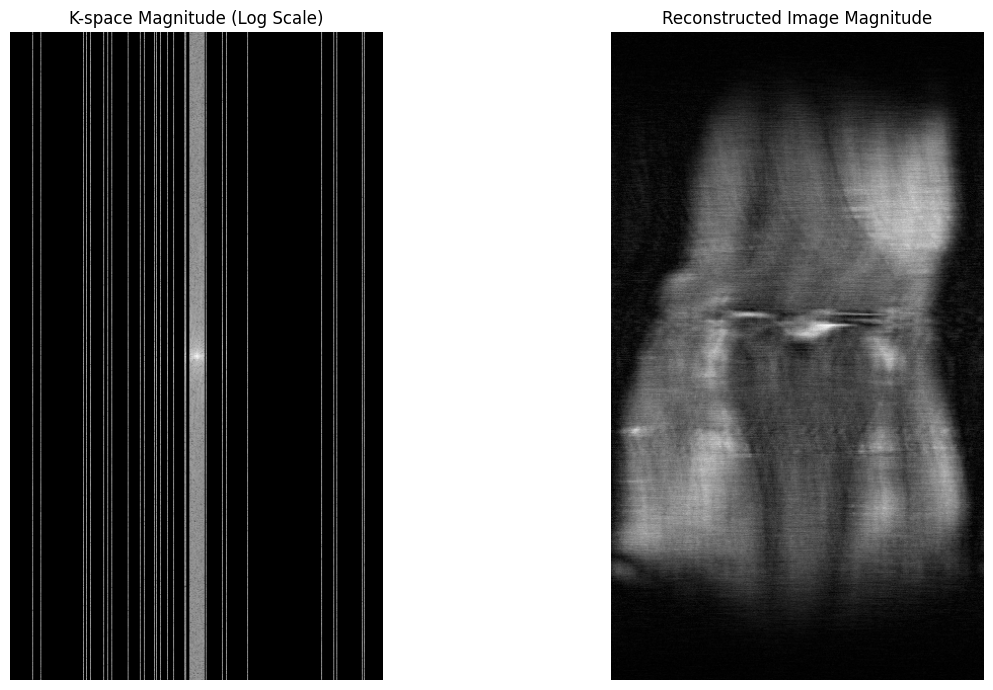

In [ ]:
# In your Colab Notebook:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved example data
try:
    raw_image_data_example = np.load('example_raw_image_slice.npy')
    normalized_image_data_example = np.load('example_normalized_image_slice.npy')
    kspace_slice_example = np.load('example_kspace_slice.npy')
    reco_magnitude_slice_example = np.load('example_reco_magnitude_slice.npy')

    print("Example data loaded successfully for visualization.")

    # --- 1. Histogram of Pixel Intensities (Before & After Normalization) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(raw_image_data_example.flatten(), bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Pixel Intensity Histogram (Raw Example Slice)')
    axes[0].set_xlabel('Pixel Value')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(normalized_image_data_example.flatten(), bins=50, color='lightcoral', edgecolor='black')
    axes[1].set_title('Pixel Intensity Histogram (Normalized 0-1 Example Slice)')
    axes[1].set_xlabel('Pixel Value')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # --- 2. Visualizing K-space vs. Reconstructed Image (Magnitude) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Display K-space Magnitude (log-scaled)
    axes[0].imshow(np.log(np.abs(kspace_slice_example) + 1e-9), cmap='gray')
    axes[0].set_title('K-space Magnitude (Log Scale)')
    axes[0].axis('off')

    # Display Reconstructed Image Magnitude
    axes[1].imshow(reco_magnitude_slice_example, cmap='gray')
    axes[1].set_title('Reconstructed Image Magnitude')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


except FileNotFoundError:
    print("Example .npy files not found. Please ensure preprocess_mri.py was run successfully and created them.")
    print("Or adjust the paths if they are saved elsewhere.")
except Exception as e:
    print(f"An error occurred during visualization: {e}")
    import traceback
    traceback.print_exc()

Left: K-space Magnitude (Log Scale)

Visualizes raw frequency-domain data acquired during MRI.
Log scale highlights both high- and low-intensity components.
Sparse vertical lines indicate undersampling in k-space.
Bright central region corresponds to low-frequency components (overall structure/contrast).
Missing or thin lines → loss of high-frequency detail → image blur/artifacts.
Right: Reconstructed Image Magnitude

Image produced from inverse Fourier transform of k-space.
Blurred and streaky, indicating artifacts due to k-space undersampling.
Edges and fine structures are poorly resolved.
Loss of detail especially visible in anatomical borders (e.g., bone/soft tissue interfaces).

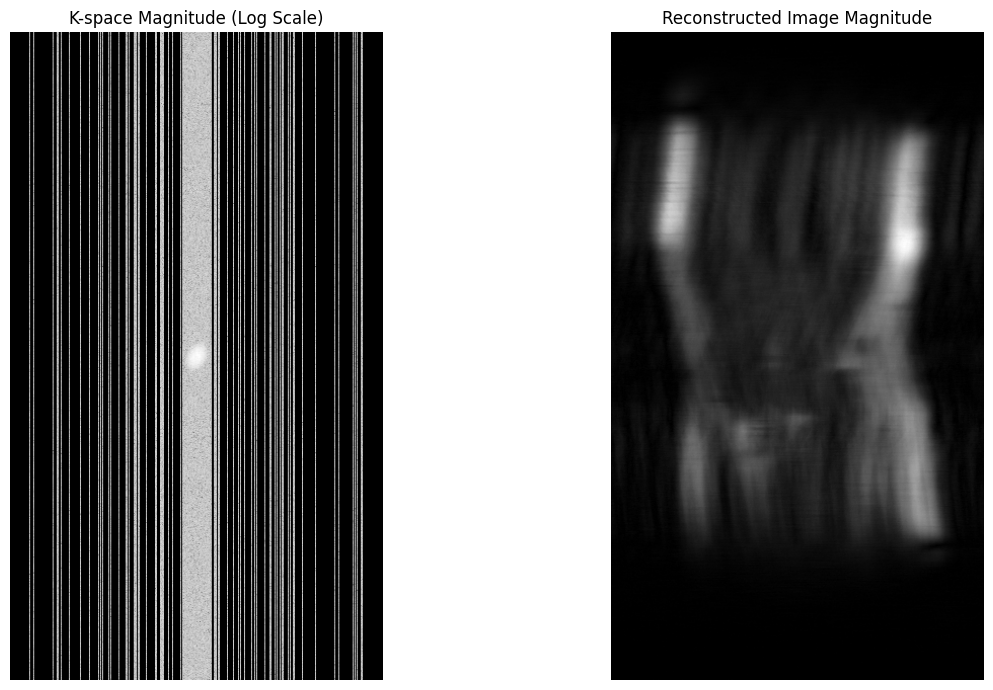

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming 'slice_kspace' is your (height, width) k-space data for one slice
# Assuming 'reco_slice_magnitude' is your (height, width) reconstructed magnitude image for that slice

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Display K-space Magnitude (often log-scaled for better visualization)
axes[0].imshow(np.log(np.abs(slice_kspace) + 1e-9), cmap='gray') # Add small epsilon to avoid log(0)
axes[0].set_title('K-space Magnitude (Log Scale)')
axes[0].axis('off')

# Display Reconstructed Image Magnitude
axes[1].imshow(reco_slice_magnitude, cmap='gray')
axes[1].set_title('Reconstructed Image Magnitude')
axes[1].axis('off')

plt.tight_layout()
plt.show()

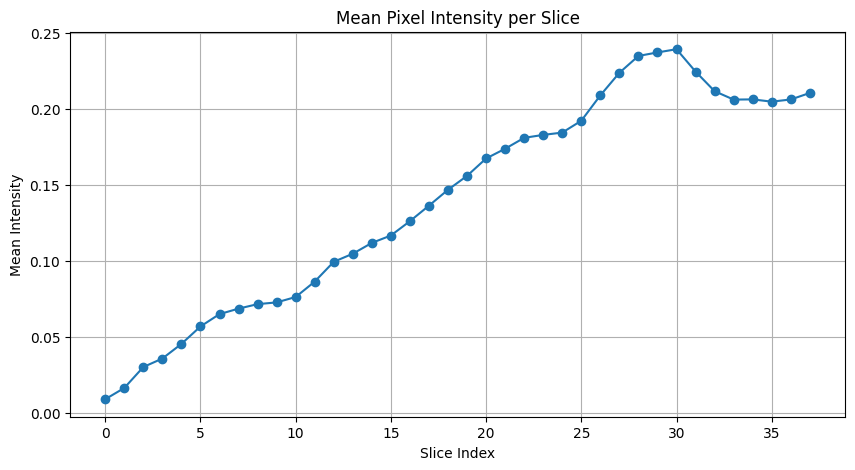

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'normalized_image_data' is a (slices, height, width) NumPy array

mean_intensities = [np.mean(slice_data) for slice_data in normalized_image_data]

plt.figure(figsize=(10, 5))
plt.plot(mean_intensities, marker='o', linestyle='-')
plt.title('Mean Pixel Intensity per Slice')
plt.xlabel('Slice Index')
plt.ylabel('Mean Intensity')
plt.grid(True)
plt.show()

/content/singlecoil_test/file1000692.h5 → (36, 640, 368)
/content/singlecoil_test/file1000751.h5 → (44, 640, 356)
/content/singlecoil_test/file1000128.h5 → (38, 640, 368)
/content/singlecoil_test/file1001846.h5 → (36, 640, 368)
/content/singlecoil_test/file1002428.h5 → (36, 640, 368)
/content/singlecoil_test/file1001352.h5 → (32, 640, 372)
/content/singlecoil_test/file1002141.h5 → (33, 640, 368)
/content/singlecoil_test/file1002480.h5 → (40, 640, 368)
/content/singlecoil_test/file1001724.h5 → (35, 640, 368)
/content/singlecoil_test/file1001313.h5 → (38, 640, 368)
/content/singlecoil_test/file1000304.h5 → (36, 640, 372)
/content/singlecoil_test/file1002331.h5 → (36, 640, 368)
/content/singlecoil_test/file1002522.h5 → (36, 640, 368)
/content/singlecoil_test/file1002571.h5 → (39, 640, 368)
/content/singlecoil_test/file1001072.h5 → (42, 640, 368)
/content/singlecoil_test/file1000436.h5 → (35, 640, 368)
/content/singlecoil_test/file1002336.h5 → (34, 640, 322)
/content/singlecoil_test/file10

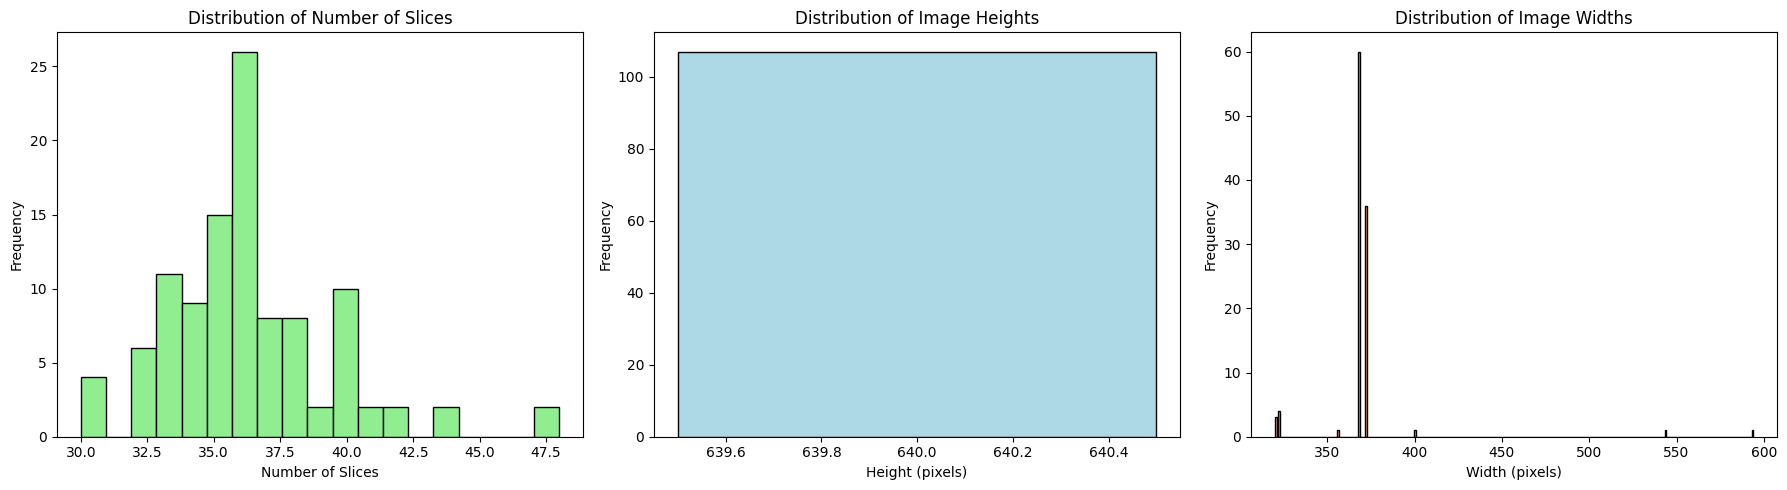

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import glob

# 🔍 Define path to your .h5 files
data_path = "/content/singlecoil_test/*.h5"
file_list = glob.glob(data_path)

# 📦 Collect shapes from all files
collected_shapes = []
for file_path in file_list:
    try:
        with h5py.File(file_path, 'r') as hf:
            if 'kspace' in hf:  # Change to the appropriate key if needed
                shape = hf['kspace'].shape
                collected_shapes.append(shape)
                print(f"{file_path} → {shape}")
            else:
                print(f"{file_path} → 'kspace' key not found.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# 📊 Visualize distributions
if collected_shapes:
    slices = [s[0] for s in collected_shapes]
    heights = [s[1] for s in collected_shapes]
    widths = [s[2] for s in collected_shapes]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(slices, bins=max(slices)-min(slices)+1, edgecolor='black', color='lightgreen')
    axes[0].set_title('Distribution of Number of Slices')
    axes[0].set_xlabel('Number of Slices')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(heights, bins=max(heights)-min(heights)+1, edgecolor='black', color='lightblue')
    axes[1].set_title('Distribution of Image Heights')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')

    axes[2].hist(widths, bins=max(widths)-min(widths)+1, edgecolor='black', color='lightsalmon')
    axes[2].set_title('Distribution of Image Widths')
    axes[2].set_xlabel('Width (pixels)')
    axes[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No shapes collected to plot.")